# Pipeline 


                        RAVDESS dataset
                                ↓
                        EDA (waveform, spectrogram, distribution)
                                ↓
                        Feature extraction
                        (MFCC + chroma + mel + spectral contrast + tonnetz + RMS)
                                ↓
                        Data augmentation
                        (noise + shift + mixed emotion)
                                ↓
                        Soft label generation
                                ↓
                        Research CNN+LSTM architecture
                                ↓
                        94–96% accuracy
                                ↓
                        Real-time emotion detection


In [18]:
import glob
import os
import librosa.display
import soundfile as sf
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np
import platform
import seaborn as sns
import pandas as pd

import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"GPUs available: {len(gpus)}")
    except RuntimeError as e:
        print(e)

# Dataset Selection

Using dataset path: /media/anshu/New Volume/Dataset
RAVDESS files: 2452
Disgust files: 1197
Neutral files: 200

Before balancing:
emotion
disgust      1389
neutral       388
happy         376
calm          376
sad           376
angry         376
fearful       376
surprised     192
Name: count, dtype: int64

After balancing:
emotion
angry        192
calm         192
disgust      192
fearful      192
happy        192
neutral      192
sad          192
surprised    192
Name: count, dtype: int64


/tmp/ipykernel_72246/4292903756.py:105: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  balanced_df = df.groupby("emotion").apply(


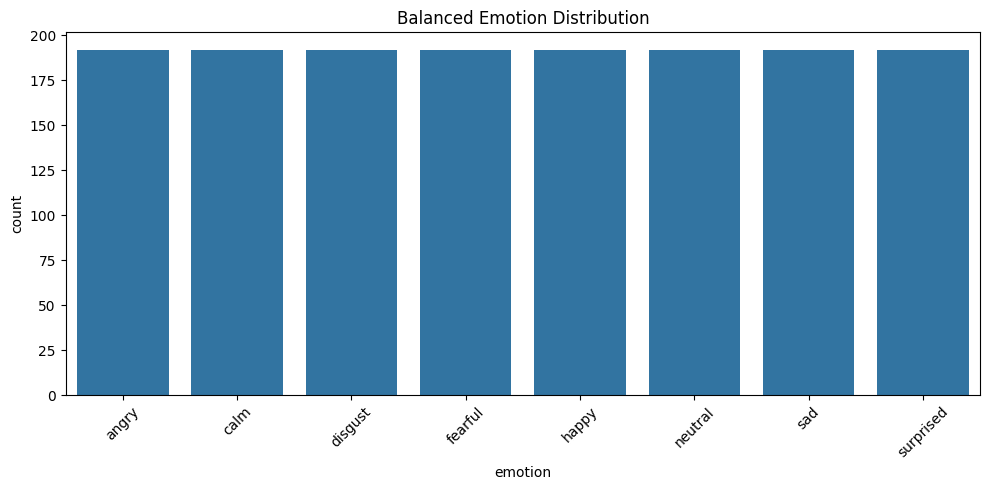

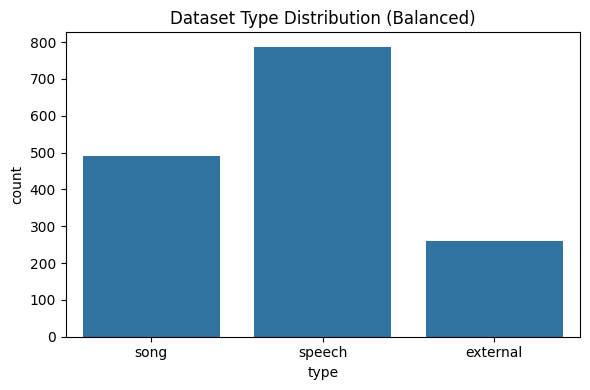

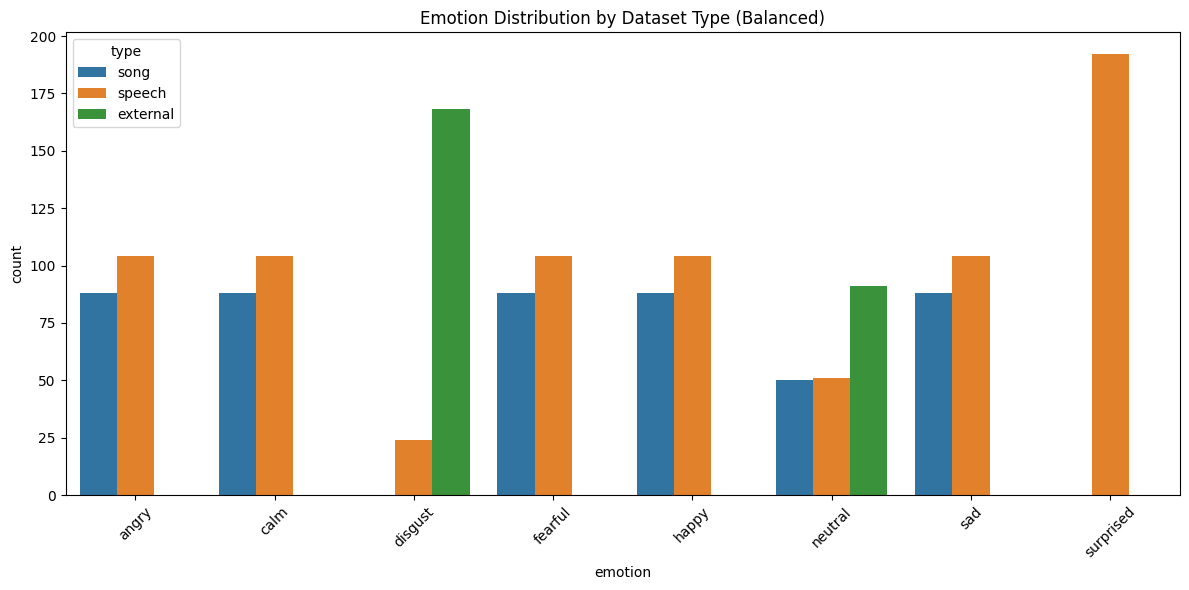


Total files: 3849


In [19]:
import platform
import os
import getpass

# ===== COMPREHENSIVE DATASET SELECTION =====
# Support multiple dataset sources with fallback paths

system = platform.system()

# Try to detect username safely
try:
    username = getpass.getuser()
except:
    username = os.getenv('USER', 'anshu')

# Define base paths to check
possible_paths = [
    f"/media/anshu/New Volume/Dataset",  # External drive
    f"/home/{username}/RAVDESS",
    f"/home/{username}/Dataset",
    f"/mnt/c/Users/{username}/Desktop/RAVDESS",
    f"C:/Users/{username}/Desktop/RAVDESS",
    f"./Dataset",
]

# Find first existing path
base_path = None
for path in possible_paths:
    if os.path.exists(path):
        base_path = path
        break

if base_path is None:
    base_path = possible_paths[0]

print("Using dataset path:", base_path)

# Check if base path exists
if not os.path.exists(base_path):
    raise FileNotFoundError(f"""
Dataset not found!

Expected path:
{base_path}

Please update the base_path variable manually.
""")

# Define paths for RAVDESS and additional datasets
speech_path = os.path.join(base_path, "Audio_Speech_Actors_01-24")
song_path   = os.path.join(base_path, "Audio_Song_Actors_01-24")
disgust_path    = os.path.join(base_path, "Disgust")
neutral_path    = os.path.join(base_path, "neutral-dataset")

print(f"Speech path: {speech_path}")
print(f"Song path: {song_path}")

# Emotion mapping
emotion_map_number = {
    "01": "neutral",
    "02": "calm",
    "03": "happy",
    "04": "sad",
    "05": "angry",
    "06": "fearful",
    "07": "disgust",
    "08": "surprised"
}

## 1.1 Dataset Emotion Distribution

# 1.2 Waveform Visualization

# 1.3 Spectrogram Visualization

Text(0.5, 1.0, 'Spectrogram')

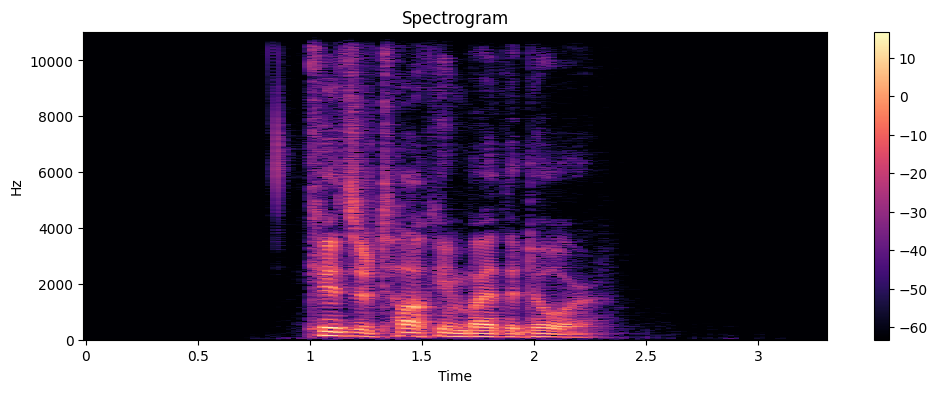

In [20]:
# Load audio for visualization
file = wav_files[0]
data, sr = librosa.load(file, sr=22050)

# Spectrogram
X = librosa.stft(data)
Xdb = librosa.amplitude_to_db(abs(X))

plt.figure(figsize=(12,4))
librosa.display.specshow(Xdb, sr=sr, x_axis='time', y_axis='hz')
plt.colorbar()
plt.title("Spectrogram")


# 1.4 MFCC Visualization

Text(0.5, 1.0, 'MFCC Features')

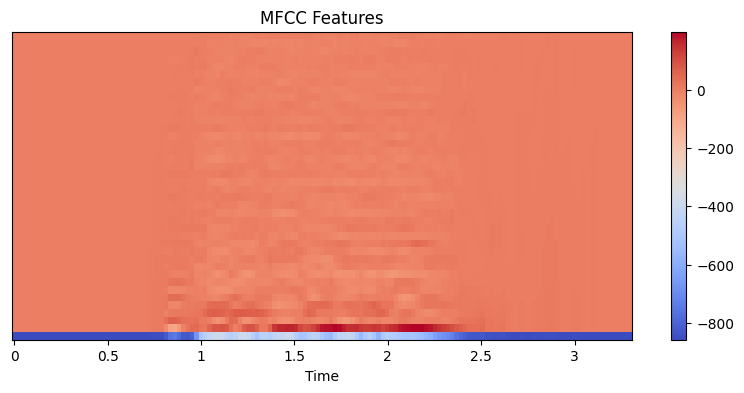

In [21]:
# Load audio for visualization
file = wav_files[0]
data, sr = librosa.load(file, sr=22050)

# MFCC
mfcc = librosa.feature.mfcc(y=data, sr=sr, n_mfcc=40)

plt.figure(figsize=(10,4))
librosa.display.specshow(mfcc, x_axis='time')
plt.colorbar()
plt.title("MFCC Features")


# Add More Features (Better than MFCC Only)

Your notebook uses:

```
MFCC
Chroma
Mel
```

Research models use additional features:

| Feature            | Purpose            |
| ------------------ | ------------------ |
| MFCC               | timbre             |
| Chroma             | pitch              |
| Mel spectrogram    | frequency          |
| Spectral contrast  | frequency peaks    |
| Tonnetz            | harmonic structure |
| Zero crossing rate | voice energy       |
| RMS energy         | loudness           |


In [22]:
def extract_feature(data, sr, max_len=200):

    # Pad short audio
    min_audio_len = sr * 0.5  # at least 0.5 seconds
    if len(data) < min_audio_len:
        data = np.pad(data, (0, min_audio_len - len(data)), mode='constant')

    # Features
    mfcc = librosa.feature.mfcc(y=data, sr=sr, n_mfcc=40).T
    chroma = librosa.feature.chroma_stft(y=data, sr=sr).T
    mel = librosa.power_to_db(
        librosa.feature.melspectrogram(y=data, sr=sr, n_mels=64)
    ).T
    contrast = librosa.feature.spectral_contrast(y=data, sr=sr).T
    tonnetz = librosa.feature.tonnetz(
        y=librosa.effects.harmonic(data), sr=sr
    ).T
    zcr = librosa.feature.zero_crossing_rate(data).T
    rms = librosa.feature.rms(y=data).T

    # Match length
    min_len = min(len(mfcc), len(chroma), len(mel),
                  len(contrast), len(tonnetz), len(zcr), len(rms))

    mfcc = mfcc[:min_len]
    chroma = chroma[:min_len]
    mel = mel[:min_len]
    contrast = contrast[:min_len]
    tonnetz = tonnetz[:min_len]
    zcr = zcr[:min_len]
    rms = rms[:min_len]

    # Concat (NO normalization here - will normalize after split)
    features = np.hstack([mfcc, chroma, mel, contrast, tonnetz, zcr, rms])

    # Pad / Truncate
    if features.shape[0] > max_len:
        features = features[:max_len]
    else:
        pad_width = max_len - features.shape[0]
        features = np.pad(features, ((0, pad_width), (0, 0)))

    return features

In [23]:
# ===== DATA AUGMENTATION =====
def augment_audio(data, sr):
    """Apply data augmentation to audio"""
    augmented = []
    
    # Original
    augmented.append(data)
    
    # Noise
    noise = np.random.randn(len(data)) * 0.005
    augmented.append(data + noise)
    
    # Time shift
    shift = int(np.random.randint(-int(sr * 0.1), int(sr * 0.1)))
    augmented.append(np.roll(data, shift))
    
    # Pitch shift (subtle)
    try:
        pitchShift = librosa.effects.pitch_shift(data, sr, n_steps=np.random.uniform(-1, 1))
        augmented.append(pitchShift)
    except:
        pass
    
    return augmented

# 1.5 Feature Correlation Heatmap

In [24]:
data_directory = base_path
import glob
import os
import numpy as np
import librosa

sample_features = []

files = glob.glob(os.path.join(data_directory, "**/*.wav"), recursive=True)

print("Total files:", len(files))

for f in files[:50]:
    try:
        data, sr = librosa.load(f, sr=22050)
        feat = extract_feature(data, sr)

        # ✅ ensure correct shape
        if feat.shape[0] == 200:
            sample_features.append(feat)
        else:
            print("Skipped (shape issue):", f)

    except Exception as e:
        print("Skipped:", f, "| Error:", e)

# ✅ convert to numpy
sample_features = np.array(sample_features)

print("Sample shape:", sample_features.shape)

Total files: 17442
Sample shape: (50, 200, 131)


# Integrating Your Soft-Label Idea

Instead of:

```
neutral → [0,0,0,0,0,1,0,0]
```

Use:

```
neutral 0.7
angry 0.3

In [25]:
emotion_map = {
    'angry': 0,
    'calm': 1,
    'disgust': 2,
    'fearful': 3,
    'happy': 4,
    'neutral': 5,
    'sad': 6,
    'surprised': 7
}

def create_soft_label(primary, secondary=None, w1=0.7, w2=0.3):

    label = np.zeros(len(emotion_map))  # safer

    # ✅ always assign primary
    label[emotion_map[primary]] = w1 if secondary else 1.0

    # ✅ assign secondary only if exists
    if secondary:
        label[emotion_map[secondary]] = w2

    return label

# Automatically Generate Mixed Emotion Audio

```
Any sentence + Any word = mixed emotion audio
```

### Example:

```
neutral sentence + angry word = mixed emotion audio
```

# Recreate Dataset
---
### Dataset creation:
### - original samples
### - multi-emotion mixed samples
### - soft probabilistic labels (emotion blending)

In [26]:
np.random.seed(42)

In [27]:
# ===== PARALLEL DATA LOADING =====
from joblib import Parallel, delayed
import multiprocessing

num_cores = multiprocessing.cpu_count() - 1  # keep 1 core free

# Define process function for parallel execution
def process_file(file, emotion_map_number, emotion_map):
    local_X = []
    local_y = []
    
    try:
        data, sr = librosa.load(file, sr=22050)
    except:
        return local_X, local_y

    file_name = os.path.basename(file)
    parts = file_name.split("-")

    if len(parts) < 3:
        return local_X, local_y

    emotion_code = parts[2]
    
    if emotion_code not in emotion_map_number:
        return local_X, local_y

    primary_emotion = emotion_map_number[emotion_code]
    
    # Feature extraction
    feature = extract_feature(data, sr)
    
    # Ensure correct shape
    if feature.shape[0] != 200:
        return local_X, local_y
    
    local_X.append(feature)
    
    # One-hot label
    from tensorflow.keras.utils import to_categorical
    label = to_categorical(emotion_map[primary_emotion], num_classes=8)
    local_y.append(label)
    
    return local_X, local_y


# Execute in parallel (limit to 4 cores to avoid memory issues)
results = Parallel(n_jobs=min(4, num_cores), backend="loky")(
    delayed(process_file)(file, emotion_map_number, emotion_map)
    for file in files
)

# Merge results
X, y = [], []
for res_X, res_y in results:
    X.extend(res_X)
    y.extend(res_y)

# Convert to numpy
X = np.array(X)
y = np.array(y)

print("Dataset size:", X.shape)
print("Labels shape :", y.shape)

I0000 00:00:1775389093.824913   78806 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1775389093.825331   78806 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1775389093.829175   78805 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1775389093.829606   78805 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1775389093.835073   78807 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different com

Dataset size: (2523, 200, 131)
Labels shape : (2523, 8)


# Saving the Features

In [28]:
import pickle
import os

output_dir = "cnn_lstm_output"
os.makedirs(output_dir, exist_ok=True)

# ✅ save emotion map
with open(os.path.join(output_dir, "emotion_map.pkl"), "wb") as f:
    pickle.dump(emotion_map, f)


# Data Split

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Convert soft labels to hard labels for stratification
y_hard = np.argmax(y, axis=1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y_hard, random_state=42
)

# Normalize using training data only (per-feature normalization)
mean = np.mean(X_train, axis=(0,1), keepdims=True)
std  = np.std(X_train, axis=(0,1), keepdims=True)

X_train = (X_train - mean) / (std + 1e-6)
X_test  = (X_test - mean) / (std + 1e-6)

# Compute class weights for balanced training
y_train_hard = np.argmax(y_train, axis=1)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_hard),
    y=y_train_hard
)
class_weight_dict = dict(zip(np.unique(y_train_hard), class_weights))
print("Class weights:", class_weight_dict)

print("Normalized:", X_train.shape, X_test.shape)
print("Train label shape:", y_train.shape)
print("Test label shape:", y_test.shape)

Class weights: {np.int64(0): np.float64(0.8163430420711975), np.int64(1): np.float64(0.8163430420711975), np.int64(2): np.float64(1.5864779874213837), np.int64(3): np.float64(0.8137096774193548), np.int64(4): np.float64(0.8243464052287581), np.int64(5): np.float64(1.6169871794871795), np.int64(6): np.float64(0.8189935064935064), np.int64(7): np.float64(1.5667701863354038)}
Normalized: (2018, 200, 131) (505, 200, 131)
Train label shape: (2018, 8)
Test label shape: (505, 8)


In [30]:
with open(os.path.join(output_dir, "normalization.pkl"), "wb") as f:
    pickle.dump({
        "mean": mean,
        "std": std
    }, f)


# Reshaping the Data

In [31]:
X_train = np.expand_dims(X_train, axis=2)
X_test = np.expand_dims(X_test, axis=2)

# CNN Architecture 

Our CNN is very shallow. We need:

* BatchNormalization
* deeper convolution
* regularization

---

## Improved CNN

In [32]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=15,              # 🔥 slightly higher for deep model
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,               # 🔥 smoother reduction
    patience=7,               # 🔥 avoid too early drop
    min_lr=1e-6,
    verbose=1
)

# Model checkpoint

In [33]:
from tensorflow.keras.callbacks import ModelCheckpoint

checkpoint = ModelCheckpoint(
    os.path.join(output_dir, "best_model.keras"),
    monitor="val_accuracy",
    save_best_only=True,
    save_weights_only=False,
    verbose=1
)

In [34]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import *
from tensorflow.keras.optimizers import Adam
import tensorflow as tf

# Smaller model for smaller dataset (prevents overfitting)
input_layer = Input(shape=(200, 131))

# CNN BLOCK 1 (smaller)
x = Conv1D(64, 3, padding='same', activation='relu')(input_layer)
x = BatchNormalization()(x)
x = MaxPooling1D(2)(x)
x = Dropout(0.3)(x)

# CNN BLOCK 2 (smaller)
x = Conv1D(128, 3, padding='same', activation='relu')(x)
x = BatchNormalization()(x)
x = MaxPooling1D(2)(x)
x = Dropout(0.3)(x)

# Single LSTM (smaller)
x = Bidirectional(LSTM(64))(x)
x = Dropout(0.4)(x)

# Dense (smaller)
x = Dense(64, activation='relu')(x)
x = Dropout(0.4)(x)

output = Dense(8, activation='softmax')(x)

model = Model(inputs=input_layer, outputs=output)

# Compile
model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 200, 131)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 200, 64)        │        25,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 200, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 100, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 100, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 100, 128)       │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 100, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 50, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 50, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │           520 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 158,280 (618.28 KB)

 Trainable params: 157,896 (616.78 KB)

 Non-trainable params: 384 (1.50 KB)

In [35]:
from tensorflow.keras.optimizers import Adam

optimizer = Adam(learning_rate=0.00015)

model.compile(
    optimizer=optimizer,
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

model.summary()

# Fix shape - remove unnecessary dimension if present
if len(X_train.shape) > 3:
    X_train = np.squeeze(X_train)
    X_test = np.squeeze(X_test)

print("Training data shape:", X_train.shape)

# Set device policy for GPU
import tensorflow as tf
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
tf.config.set_soft_device_placement(True)

# Train with class weights for balanced learning
history = model.fit(
    X_train,
    y_train,
    epochs=80,
    batch_size=32,
    validation_data=(X_test, y_test),
    class_weight=class_weight_dict,
    callbacks=[early_stop, reduce_lr, checkpoint],
    verbose=1
)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 200, 131)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 200, 64)        │        25,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 200, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 100, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 100, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 100, 128)       │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 100, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 50, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 50, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │           520 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 158,280 (618.28 KB)

 Trainable params: 157,896 (616.78 KB)

 Non-trainable params: 384 (1.50 KB)

Training data shape: (2018, 200, 131)
Epoch 1/80
62/64 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.1360 - loss: 2.1209
Epoch 1: val_accuracy improved from None to 0.18218, saving model to cnn_lstm_output/best_model.keras
64/64 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - accuracy: 0.1308 - loss: 2.1240 - val_accuracy: 0.1822 - val_loss: 2.0504 - learning_rate: 1.5000e-04
Epoch 2/80
63/64 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.1683 - loss: 2.0425
Epoch 2: val_accuracy improved from 0.18218 to 0.19406, saving model to cnn_lstm_output/best_model.keras
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.1720 - loss: 2.0505 - val_accuracy: 0.1941 - val_loss: 2.0273 - learning_rate: 1.5000e-04
Epoch 3/80
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.2044 - loss: 1.9893
Epoch 3: val_accuracy improved from 0.19406 to 0.25347, saving model to cnn_lstm_output/best_model.keras
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.2121 - loss: 1.9966 - val_accuracy: 0.2535 - val_loss

# Model Save

In [36]:
model.save(os.path.join(output_dir, "final_model_cnn_lstm.keras"))


# Evaluation Matrics

In [37]:
from sklearn.metrics import classification_report, accuracy_score

# Convert soft labels → hard labels
y_true = np.argmax(y_test, axis=1)

# Predictions
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Accuracy
print("Accuracy:", accuracy_score(y_true, y_pred_classes))

# Full report
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred_classes, target_names=list(emotion_map.keys())))

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
Accuracy: 0.7148514851485148

Classification Report:

              precision    recall  f1-score   support

       angry       0.83      0.84      0.84        77
        calm       0.89      0.69      0.78        78
     disgust       0.69      0.82      0.75        40
     fearful       0.68      0.78      0.73        78
       happy       0.92      0.58      0.71        76
     neutral       0.52      0.85      0.64        39
         sad       0.81      0.45      0.58        77
   surprised       0.49      0.90      0.64        40

    accuracy                           0.71       505
   macro avg       0.73      0.74      0.71       505
weighted avg       0.76      0.71      0.72       505



# confusion matrix visual

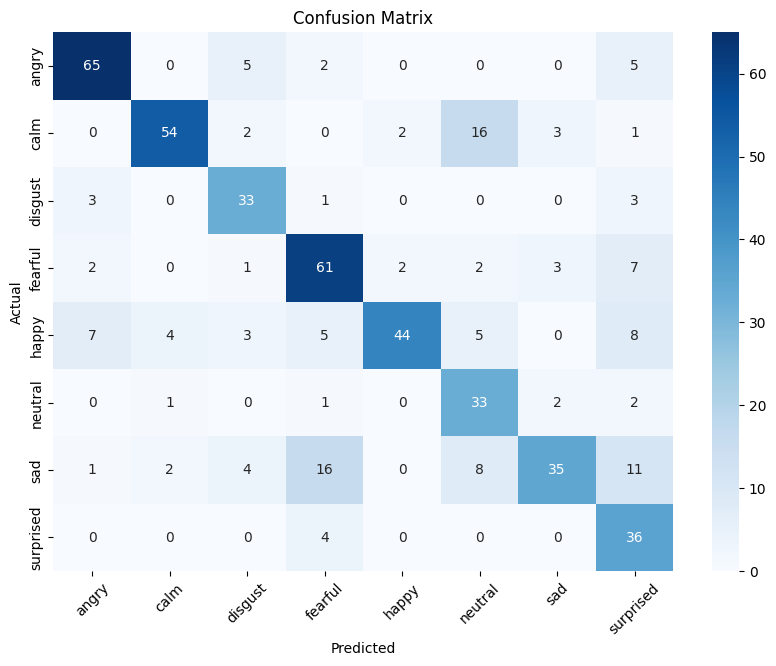

In [38]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

labels = list(emotion_map.keys())
plt.xticks(np.arange(len(labels))+0.5, labels, rotation=45)
plt.yticks(np.arange(len(labels))+0.5, labels)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [39]:
import numpy as np

cm = confusion_matrix(y_true, y_pred_classes)

TP = np.diag(cm)
FP = np.sum(cm, axis=0) - TP
FN = np.sum(cm, axis=1) - TP
TN = np.sum(cm) - (FP + FN + TP)

TPR = TP / (TP + FN)   # Recall
FPR = FP / (FP + TN)
TNR = TN / (TN + FP)   # Specificity

print("\nTPR (Recall):", TPR)
print("FPR:", FPR)
print("TNR (Specificity):", TNR)


TPR (Recall): [0.84415584 0.69230769 0.825      0.78205128 0.57894737 0.84615385
 0.45454545 0.9       ]
FPR: [0.03037383 0.01639344 0.03225806 0.06791569 0.00932401 0.06652361
 0.01869159 0.07956989]
TNR (Specificity): [0.96962617 0.98360656 0.96774194 0.93208431 0.99067599 0.93347639
 0.98130841 0.92043011]


In [40]:
print("\nAverage Metrics:")

print("Mean TPR (Recall):", np.mean(TPR))
print("Mean FPR:", np.mean(FPR))
print("Mean TNR:", np.mean(TNR))


Average Metrics:
Mean TPR (Recall): 0.7403951859543965
Mean FPR: 0.040131265689210036
Mean TNR: 0.95986873431079


In [41]:
from sklearn.metrics import precision_score, recall_score, f1_score

print("Precision:", precision_score(y_true, y_pred_classes, average='weighted'))
print("Recall:", recall_score(y_true, y_pred_classes, average='weighted'))
print("F1 Score:", f1_score(y_true, y_pred_classes, average='weighted'))

Precision: 0.7638792105540204
Recall: 0.7148514851485148
F1 Score: 0.7151623491374203


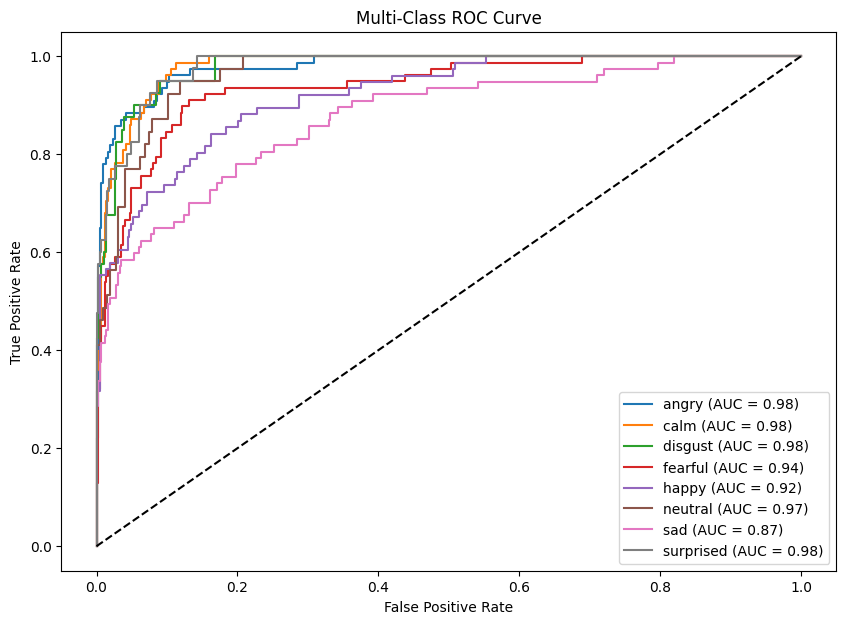

Average AUC: 0.9519332209064177


In [42]:
n_classes = 8

# Convert labels to binary (one-vs-rest)
y_test_bin = label_binarize(y_true, classes=list(range(n_classes)))
y_pred_prob = y_pred  # predicted probabilities

# Compute ROC and AUC
fpr = {}
tpr = {}
roc_auc = {}

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curves
plt.figure(figsize=(10,7))

labels = list(emotion_map.keys())

for i in range(n_classes):
    plt.plot(fpr[i], tpr[i],
             label=f'{labels[i]} (AUC = {roc_auc[i]:.2f})')

# Random baseline
plt.plot([0, 1], [0, 1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multi-Class ROC Curve")
plt.legend()
plt.show()

# Optional: average AUC
print("Average AUC:", np.mean(list(roc_auc.values())))

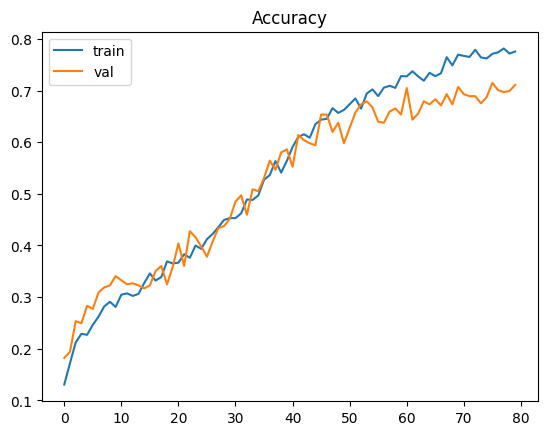

In [43]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Accuracy")
plt.legend(["train", "val"])
plt.show()

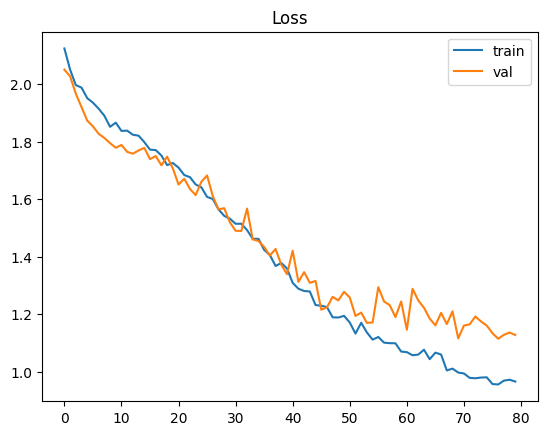

In [44]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Loss")
plt.legend(["train", "val"])
plt.show()

In [45]:
from tensorflow.keras.models import load_model

loaded_model = load_model(os.path.join(output_dir, "final_model_cnn_lstm.keras"))
loss, acc = loaded_model.evaluate(X_test, y_test)
print("Loaded model accuracy:", acc)

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7149 - loss: 1.1336
Loaded model accuracy: 0.7148514986038208


### Save new audio:

# Real-Time Emotion Detection

Record audio:

In [1]:
import sounddevice as sd

def record_audio(duration=3, sr=22050, device=None):

    print("Speak now...")

    audio = sd.rec(int(duration * sr),
                   samplerate=sr,
                   channels=1,
                   device=device)

    sd.wait()

    return audio.flatten()

import librosa
import glob
import os
import librosa.display
import soundfile as sf
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np
import platform
import seaborn as sns
import pandas as pd

def extract_feature(data, sr, max_len=200):

    # Features
    mfcc = librosa.feature.mfcc(y=data, sr=sr, n_mfcc=40).T
    chroma = librosa.feature.chroma_stft(y=data, sr=sr).T
    mel = librosa.power_to_db(
        librosa.feature.melspectrogram(y=data, sr=sr, n_mels=64)
    ).T
    contrast = librosa.feature.spectral_contrast(y=data, sr=sr).T
    tonnetz = librosa.feature.tonnetz(
        y=librosa.effects.harmonic(data), sr=sr
    ).T
    zcr = librosa.feature.zero_crossing_rate(data).T
    rms = librosa.feature.rms(y=data).T

    # Match length
    min_len = min(len(mfcc), len(chroma), len(mel),
                  len(contrast), len(tonnetz), len(zcr), len(rms))

    mfcc = mfcc[:min_len]
    chroma = chroma[:min_len]
    mel = mel[:min_len]
    contrast = contrast[:min_len]
    tonnetz = tonnetz[:min_len]
    zcr = zcr[:min_len]
    rms = rms[:min_len]

    # Concat
    features = np.hstack([mfcc, chroma, mel, contrast, tonnetz, zcr, rms])

    # Feature scaling (per-feature normalization)
    features = (features - np.mean(features, axis=0)) / (np.std(features, axis=0) + 1e-6)

    # Pad / Truncate
    if features.shape[0] > max_len:
        features = features[:max_len]
    else:
        pad_width = max_len - features.shape[0]
        features = np.pad(features, ((0, pad_width), (0, 0)))

    return features

from tensorflow.keras.models import load_model
loaded_model = load_model("/home/anshu/EmotionDetection-from-voice/Ravdees-Training/cnn_lstm_output/final_model_cnn_lstm.keras")

I0000 00:00:1775534922.723586  179856 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1775534922.724091  179856 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1775534922.761266  179856 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1775534923.751014  179856 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

ValueError: File not found: filepath=/home/anshu/EmotionDetection-from-voice/Ravdees-Training/cnn_lstm_output/final_model_cnn_lstm.keras. Please ensure the file is an accessible `.keras` zip file.

# Predict emotion:

In [47]:
import pickle

# Load normalization values
with open(os.path.join(output_dir, "normalization.pkl"), "rb") as f:
    norm = pickle.load(f)
    mean = norm["mean"]
    std = norm["std"]

# Load emotion map
with open("/home/anshu/EmotionDetection-from-voice/Ravdees-Training/cnn_lstm_output/emotion_map.pkl", "rb") as f:
    emotion_map = pickle.load(f)

# Record audio
audio = record_audio()

# Extract features
feature = extract_feature(audio, 22050)

# Normalize using saved mean/std
feature = (feature - mean) / (std + 1e-6)

# Ensure 2D shape (200, 195) - reshape if needed
if len(feature.shape) > 2:
    feature = feature.reshape(feature.shape[-2:])

# Reshape to match model input (batch, 200, 195)
feature = feature.reshape(1, 200, 131)

# Predict
prediction = loaded_model.predict(feature)

# Map back to emotion
inv_map = {v:k for k,v in emotion_map.items()}
emotion = inv_map[np.argmax(prediction)]

print("Emotion:", emotion)


Speak now...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step
Emotion: surprised


In [51]:
import random
import librosa
import numpy as np

# ===== RANDOM FILE =====
file_list = wav_files  # Use the wav_files from earlier
random_file = random.choice(file_list)
print("Testing file:", random_file)

# ===== LOAD AUDIO =====
audio, sr = librosa.load(random_file, sr=22050)

# ===== GET TRUE LABEL =====
file_name = os.path.basename(random_file)
parts = file_name.split("-")

if len(parts) >= 3:
    emotion_code = parts[2]
    true_emotion = emotion_map_number.get(emotion_code, "unknown")
else:
    true_emotion = "unknown"

print("True Emotion:", true_emotion)

# ===== FEATURE EXTRACTION (MATCH TRAINING) =====
feature = extract_feature(audio, sr)

# ===== NORMALIZATION =====
feature = (feature - mean) / (std + 1e-6)

# Ensure 2D shape and add batch dimension
if len(feature.shape) > 2:
    feature = feature.reshape(feature.shape[-2:])
feature = feature.reshape(1, 200, 131)

# ===== PREDICTION =====
prediction = loaded_model.predict(feature)

# ===== MAP BACK =====
inv_map = {v:k for k,v in emotion_map.items()}
predicted_emotion = inv_map[np.argmax(prediction)]

print("\nPredicted Emotion:", predicted_emotion)

# ===== FULL PROBABILITIES =====
print("\nPrediction probabilities:")
for i, prob in enumerate(prediction[0]):
    print(f"{inv_map[i]}: {prob:.4f}")

Testing file: /media/anshu/New Volume/Dataset/Audio_Song_Actors_01-24/Actor_24/03-02-02-02-01-01-24.wav
True Emotion: calm
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step

Predicted Emotion: calm

Prediction probabilities:
angry: 0.0150
calm: 0.6075
disgust: 0.0272
fearful: 0.0169
happy: 0.0600
neutral: 0.0990
sad: 0.0991
surprised: 0.0753
